In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df = pd.read_excel(r"C:\Users\kokki\Downloads\BlinkIT Grocery Data.xlsx")

In [4]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [5]:
df.isna().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [8]:
df.describe()

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2016.450546,0.066132,12.857645,140.992783,3.965857
std,3.189396,0.051598,4.643456,62.275067,0.605651
min,2011.000000,0.000000,4.555000,31.290000,1.000000
25%,2014.000000,0.026989,8.773750,93.826500,4.000000
50%,2016.000000,0.053931,12.600000,143.012800,4.000000
75%,2018.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


In [12]:
df.columns 

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [15]:
Total_sales =df["Sales"].sum()
print("The Total Sales:", Total_sales)

The Total Sales: 1201681.4928


In [18]:
Average_sales =df["Sales"].mean()
print("The Average Sales:", Average_sales)

The Average Sales: 140.99278338613163


In [22]:
no_of_items = df['Item Identifier'].count()
print("The no of items:",no_of_items)


The no of items: 8523


In [23]:
Average_rating = df['Rating'].mean()
print("The Average rating:", Average_rating)

The Average rating: 3.965857092573038


In [27]:
df['Item Fat Content'] = df['Item Fat Content'].replace({
    "LF" : "Low Fat",
    "low fat" : "Low Fat",
    "reg" : "Regular"    
})
    


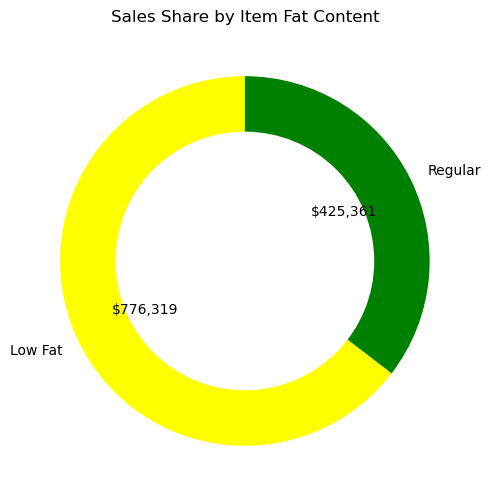

In [31]:
import matplotlib.pyplot as plt


sales = df.groupby('Item Fat Content')['Sales'].sum()


def absolute_value(val):
    total = sum(sales)
    absolute = int(val/100 * total)
    return f"${absolute:,}"   

plt.figure(figsize=(6,6))
plt.pie(
    sales,
    labels=sales.index,
    autopct=absolute_value,   
    startangle=90,
    colors=['yellow', 'green']
)


centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sales Share by Item Fat Content")
plt.show()

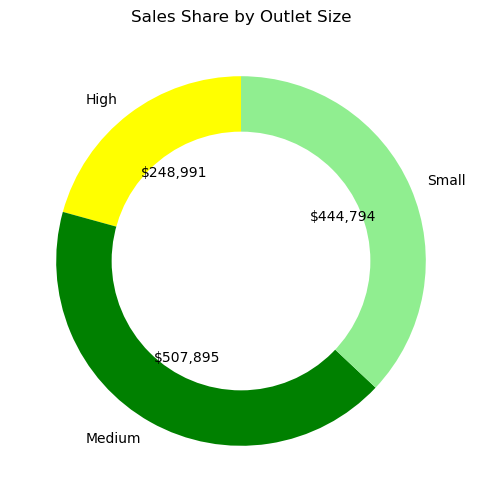

In [34]:
import matplotlib.pyplot as plt


sales = df.groupby('Outlet Size')['Sales'].sum()


def absolute_value(val):
    total = sum(sales)
    absolute = int(val/100 * total)
    return f"${absolute:,}"

plt.figure(figsize=(6,6))
plt.pie(
    sales,
    labels=sales.index,
    autopct=absolute_value,
    startangle=90,
    colors=['yellow', 'green', 'lightgreen']   
)

# Donut hole
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sales Share by Outlet Size")
plt.show()

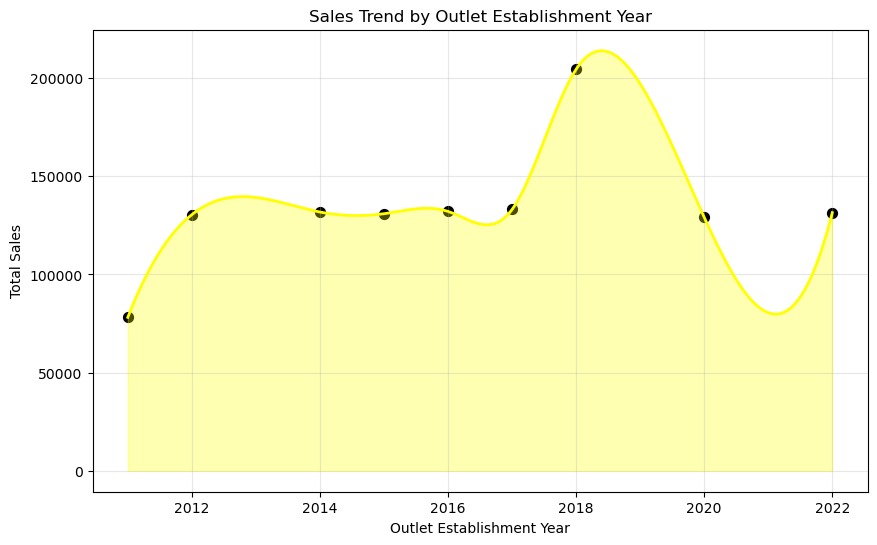

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.interpolate import make_interp_spline


sales_by_year = df.groupby("Outlet Establishment Year")["Sales"].sum().reset_index()

x = sales_by_year["Outlet Establishment Year"]
y = sales_by_year["Sales"]

x_smooth = np.linspace(x.min(), x.max(), 300)
spl = make_interp_spline(x, y, k=3)   # cubic spline
y_smooth = spl(x_smooth)

plt.figure(figsize=(10,6))


plt.plot(
    x_smooth,
    y_smooth,
    color="yellow",
    linewidth=2
)


plt.scatter(
    x,
    y,
    color="black",
    s=50
)


plt.fill_between(
    x_smooth,
    y_smooth,
    color="yellow",
    alpha=0.3
)

plt.title("Sales Trend by Outlet Establishment Year")
plt.xlabel("Outlet Establishment Year")
plt.ylabel("Total Sales")
plt.grid(True, alpha=0.3)

plt.show()

C:\Users\kokki\AppData\Local\Temp\ipykernel_29332\3057742649.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


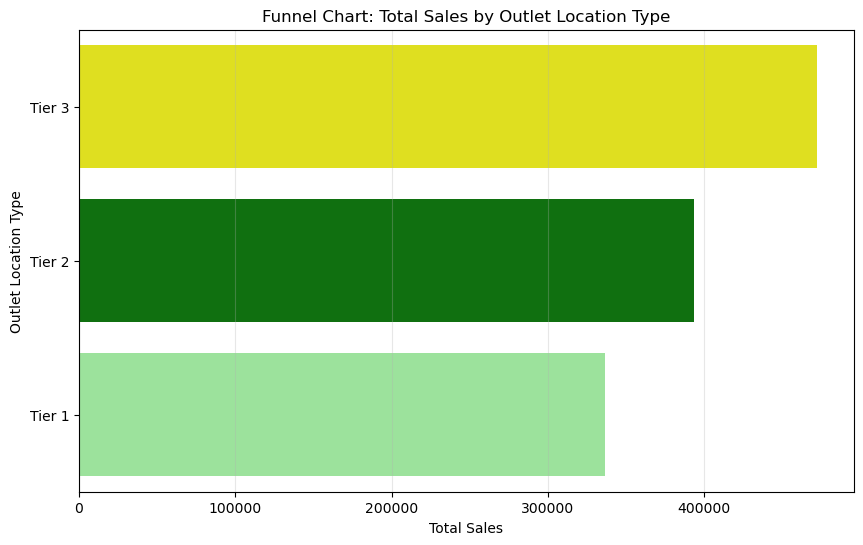

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
sales_funnel = df.groupby("Outlet Location Type")["Sales"].sum().reset_index()

# Sort from highest to lowest (important for funnel shape)
sales_funnel = sales_funnel.sort_values("Sales", ascending=False)

plt.figure(figsize=(10,6))

# Horizontal bar chart (funnel style)
sns.barplot(
    data=sales_funnel,
    x="Sales",
    y="Outlet Location Type",
    palette=["yellow", "green", "lightgreen"]  # funnel colors
)

plt.title("Funnel Chart: Total Sales by Outlet Location Type")
plt.xlabel("Total Sales")
plt.ylabel("Outlet Location Type")

# Remove grid for cleaner funnel look
plt.grid(axis='x', alpha=0.3)

plt.show()

C:\Users\kokki\AppData\Local\Temp\ipykernel_29332\1392395494.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\kokki\AppData\Local\Temp\ipykernel_29332\1392395494.py:13: UserWarning: 
The palette list has fewer values (15) than needed (16) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


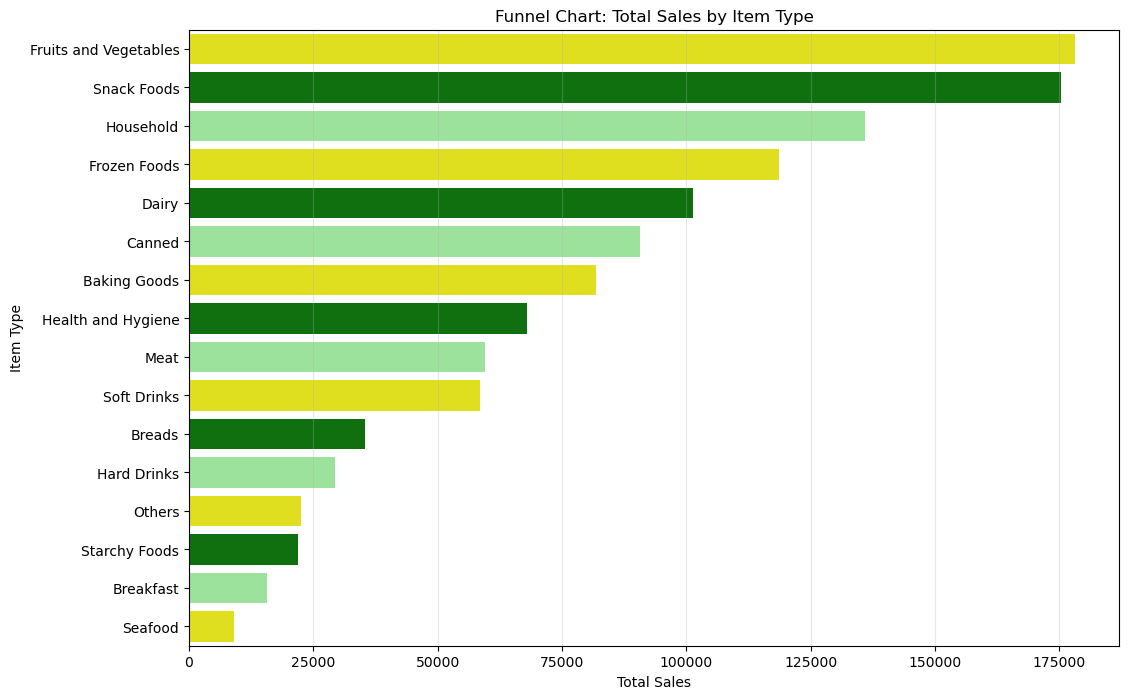

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
sales_funnel = df.groupby("Item Type")["Sales"].sum().reset_index()

# Sort from highest to lowest for funnel shape
sales_funnel = sales_funnel.sort_values("Sales", ascending=False)

plt.figure(figsize=(12,8))

# Horizontal funnel-style bar chart
sns.barplot(
    data=sales_funnel,
    x="Sales",
    y="Item Type",
    palette=["yellow", "green", "lightgreen"] * 5   # repeats colors if many item types
)

plt.title("Funnel Chart: Total Sales by Item Type")
plt.xlabel("Total Sales")
plt.ylabel("Item Type")

plt.grid(axis='x', alpha=0.3)

plt.show()

In [18]:
import pandas as pd

numericals = ['Sales','Rating','Item Weight','Item Visibility']

for i in numericals:
    df[i] = pd.to_numeric(df[i], errors='coerce')
    

In [19]:
df.groupby('Rating')["Sales"].sum().sort_values(ascending = False)

Rating
4.0    475733.6076
4.3     95714.5790
4.2     93304.8346
4.1     71333.3762
5.0     59282.5424
4.4     49537.8988
3.9     42981.2392
4.5     37460.5842
3.8     35110.2596
3.7     30335.7108
3.0     26753.7282
3.5     24021.8216
3.6     21003.6528
3.3     16485.8214
4.6     15478.0582
1.0     14930.7728
3.4     11967.7654
4.7     10819.1266
2.0     10195.2296
4.8      8691.3610
3.2      7694.6744
2.5      7358.1952
2.8      6826.5712
3.1      6755.9384
2.3      3610.6204
2.9      3558.8984
2.7      3061.0116
4.9      2211.6166
2.6      1974.1918
1.5      1612.5334
2.4      1583.4408
2.2      1368.2480
1.7      1027.8604
1.8       753.4804
2.1       373.3796
1.3       266.1516
1.2       223.5404
1.4       172.8396
1.9       106.3306
Name: Sales, dtype: float64

In [20]:
df.groupby('Outlet Type')["Sales"].sum().sort_values(ascending = False)

Outlet Type
Supermarket Type1    787549.8928
Grocery Store        151939.1490
Supermarket Type2    131477.7764
Supermarket Type3    130714.6746
Name: Sales, dtype: float64

In [21]:
print("The total sales:", df['Sales'].sum())
print("The max sales:", df['Sales'].max())
print("The mini sales:", df['Sales'].min())
print("The Average sales:", df['Sales'].mean())

The total sales: 1201681.4928
The max sales: 266.8884
The mini sales: 31.29
The Average sales: 140.99278338613163


In [22]:
df.groupby('Outlet Type')["Rating"].mean().sort_values(ascending = False )

Outlet Type
Grocery Store        3.985873
Supermarket Type2    3.971228
Supermarket Type1    3.963242
Supermarket Type3    3.952941
Name: Rating, dtype: float64

In [24]:
df.groupby("Item Fat Content")["Sales"].sum().sort_values(ascending = False)


Item Fat Content
Low Fat    776319.6884
Regular    425361.8044
Name: Sales, dtype: float64

In [25]:
df["outlet age"] = 2026-df[ 'Outlet Establishment Year']

In [26]:
df.groupby("outlet age")["Sales"].mean().sort_values(ascending = False)

outlet age
9     143.122481
10    142.057387
4     141.678638
12    141.425982
11    140.950248
15    140.777597
14    140.297699
8     139.796485
6     139.421124
Name: Sales, dtype: float64

In [27]:
df.sort_values("Sales",ascending = False).head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating,outlet age
3398,Regular,FDR25,Canned,2016,OUT046,Tier 1,Small,Supermarket Type1,0.139522,17.000,266.8884,4.0,10
183,Low Fat,FDS13,Canned,2020,OUT017,Tier 2,Small,Supermarket Type1,0.125210,6.465,266.8884,5.0,6
1775,Low Fat,NCS29,Health and Hygiene,2014,OUT013,Tier 3,High,Supermarket Type1,0.069488,9.000,266.6884,4.3,12
559,Low Fat,FDK51,Dairy,2011,OUT010,Tier 3,Medium,Grocery Store,0.008763,19.850,266.6884,4.7,15
5419,Low Fat,FDS13,Canned,2018,OUT019,Tier 1,Small,Grocery Store,0.217994,NaN,266.5884,2.9,8
3563,Low Fat,NCS29,Health and Hygiene,2017,OUT035,Tier 2,Small,Supermarket Type1,0.069532,9.000,266.5884,4.0,9
2720,Low Fat,NCS29,Health and Hygiene,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.069654,9.000,266.2884,4.1,14
6202,Low Fat,FDK51,Dairy,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.005243,19.850,266.1884,4.0,14
4977,Low Fat,FDS13,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.124403,6.465,266.1884,3.4,12
2131,Low Fat,NCM05,Health and Hygiene,2018,OUT019,Tier 1,Small,Grocery Store,0.104784,NaN,266.0226,4.2,8


In [28]:
df["Item Type"].value_counts()

Item Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

In [29]:
df.corr(numeric_only=True)

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating,outlet age
Outlet Establishment Year,1.000000,-0.058087,-0.004589,-0.000654,0.000414,-1.000000
Item Visibility,-0.058087,1.000000,-0.014048,-0.001315,0.000798,0.058087
Item Weight,-0.004589,-0.014048,1.000000,0.027141,0.002711,0.004589
Sales,-0.000654,-0.001315,0.027141,1.000000,0.011329,0.000654
Rating,0.000414,0.000798,0.002711,0.011329,1.000000,-0.000414
outlet age,-1.000000,0.058087,0.004589,0.000654,-0.000414,1.000000


In [30]:
import seaborn as sns
pt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
pt.title("Correlation Heatmap")
pt.show()

NameError: name 'pt' is not defined

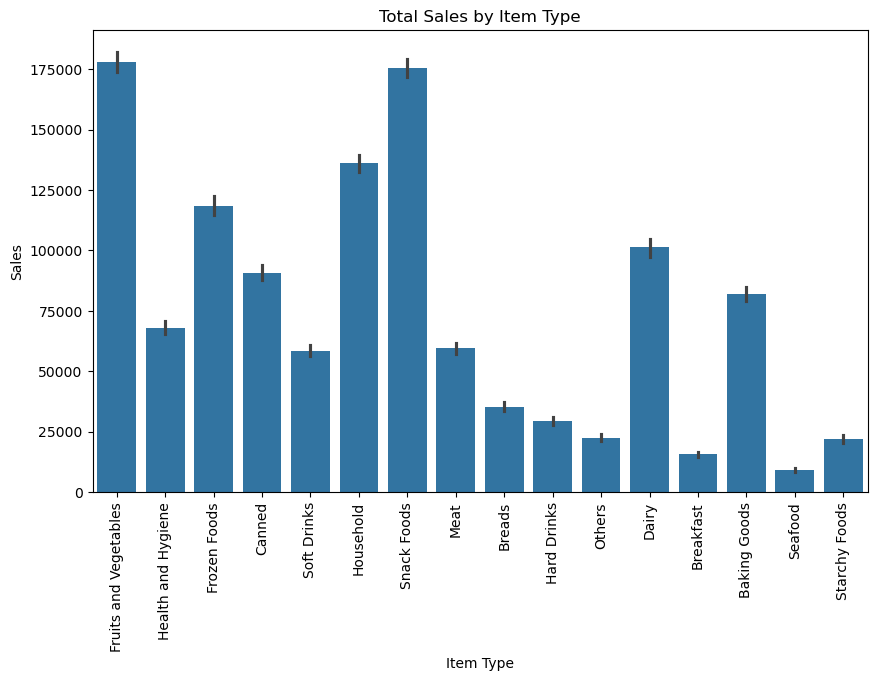

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(x='Item Type', y='Sales', data=df, estimator=sum)
plt.xticks(rotation=90)
plt.title("Total Sales by Item Type")
plt.show()

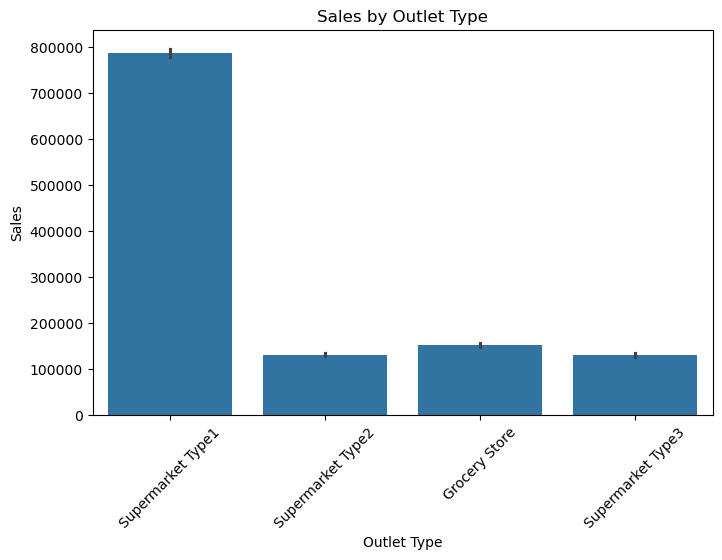

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(x='Outlet Type', y='Sales', data=df, estimator=sum)

plt.title("Sales by Outlet Type")
plt.xticks(rotation=45)
plt.show()

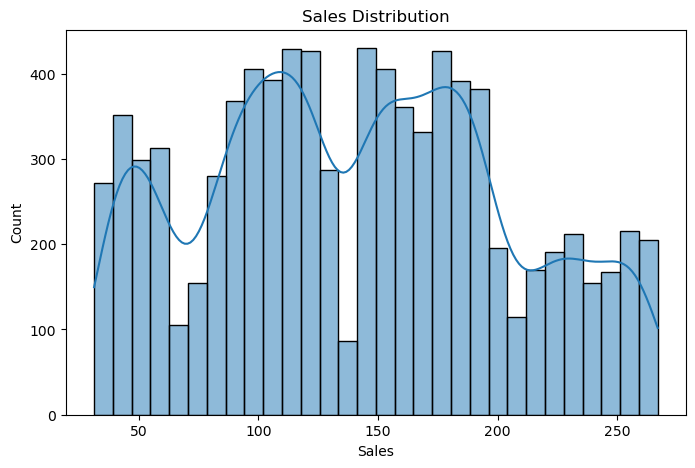

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=30, kde=True)

plt.title("Sales Distribution")
plt.show()

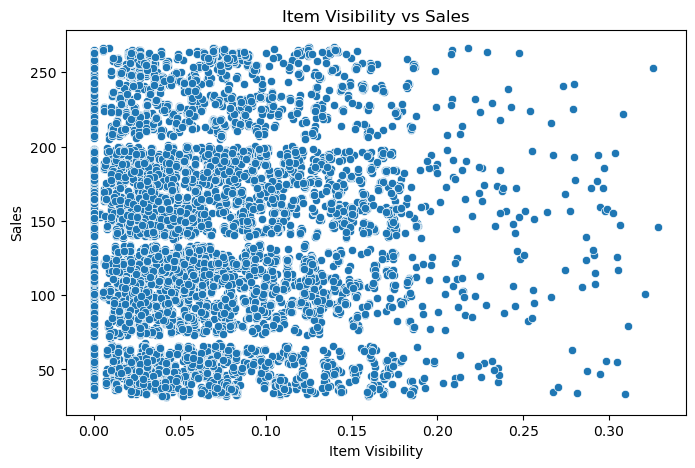

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Item Visibility', y='Sales', data=df)

plt.title("Item Visibility vs Sales")
plt.show()

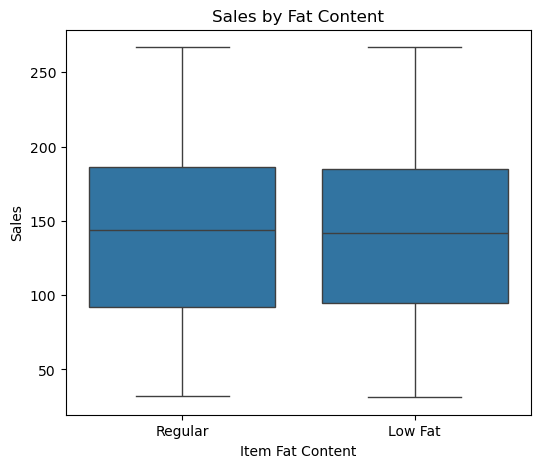

In [35]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Item Fat Content', y='Sales', data=df)

plt.title("Sales by Fat Content")
plt.show()

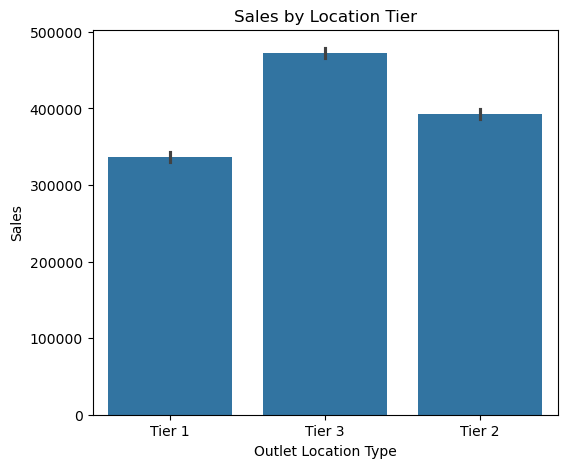

In [36]:
plt.figure(figsize=(6,5))
sns.barplot(x='Outlet Location Type', y='Sales', data=df, estimator=sum)

plt.title("Sales by Location Tier")
plt.show()

In [37]:
total_items = df['Item Identifier'].nunique()
print("Total Unique Items:", total_items)

Total Unique Items: 1559


In [38]:
df.to_csv("blinkit_data.csv", index=False)

In [39]:
df.to_excel("blinkit_data.xlsx", index=False)

In [40]:
df.columns 


Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating', 'outlet age'],
      dtype='object')

In [41]:
df.groupby('Item Fat Content')['Sales'].sum().sort_values(ascending = False)


Item Fat Content
Low Fat    776319.6884
Regular    425361.8044
Name: Sales, dtype: float64

In [43]:
df.groupby('Item Fat Content')['Sales'].mean().sort_values(ascending = False)

Item Fat Content
Regular    141.50426
Low Fat    140.71410
Name: Sales, dtype: float64

In [44]:
df.groupby('Item Fat Content')['Sales'].nunique().sort_values(ascending = False)

Item Fat Content
Low Fat    4263
Regular    2504
Name: Sales, dtype: int64

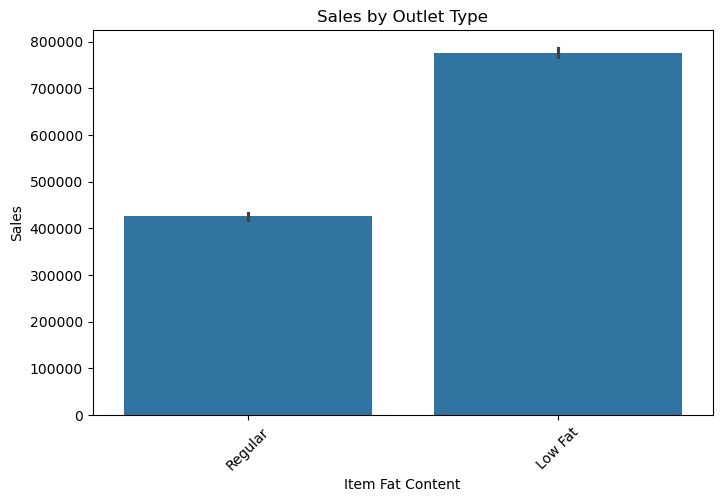

In [42]:
plt.figure(figsize=(8,5))
sns.barplot(x='Item Fat Content', y='Sales', data=df, estimator=sum)

plt.title("Sales by Outlet Type")
plt.xticks(rotation=45)
plt.show()